int64      191
float64      5
Name: count, dtype: int64
TOP 10 FEATURES
              Feature  Importance
4   time_since_signup    0.633560
10         source_SEO    0.045624
12         browser_IE    0.045543
14     browser_Safari    0.027127
11    browser_FireFox    0.025822
15              sex_M    0.025799
9       source_Direct    0.025584
5         hour_of_day    0.025095
0      purchase_value    0.022508
1                 age    0.021260


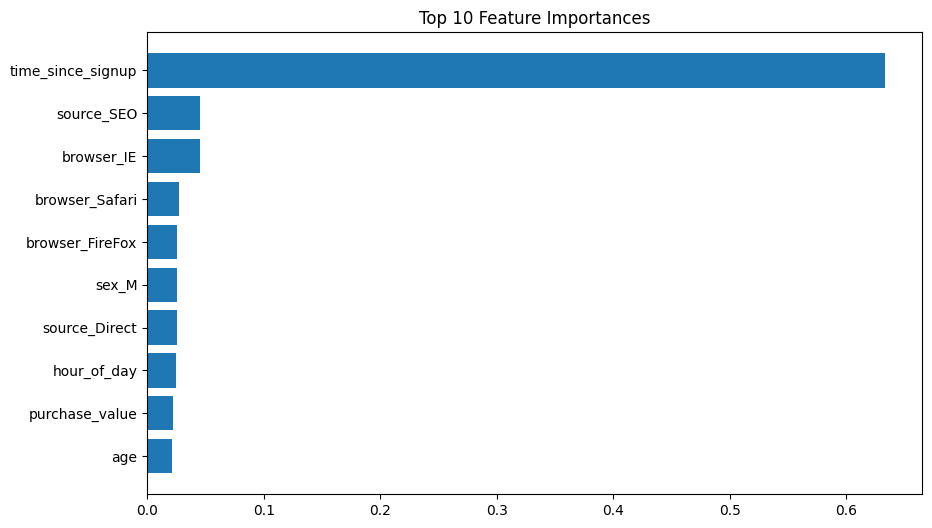

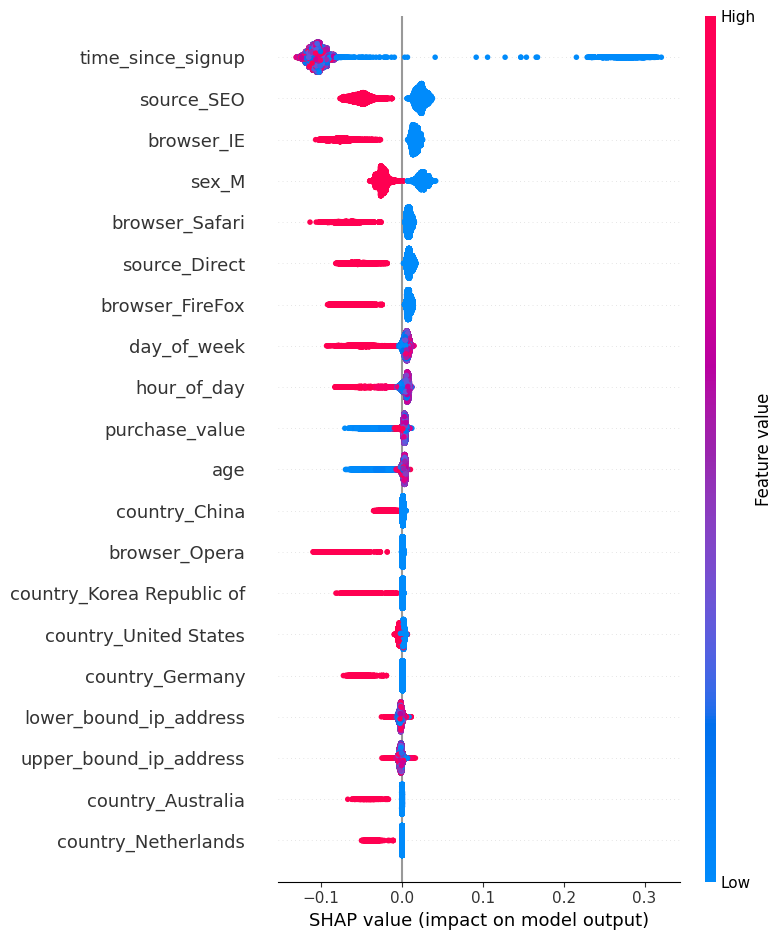

TRUE POSITIVE: 11359
FALSE POSITIVE: 79018
FALSE NEGATIVE: 60640
Force plots require notebook rendering. Run each force plot in a separate cell if they do not display.

INTERPRETATION TEMPLATE
1. Compare SHAP importance with Random Forest feature importance.
2. Identify top 5 fraud drivers from SHAP summary plot.
3. Explain unexpected findings.
4. Write at least 3 business recommendations based on top fraud indicators.


In [8]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# LOAD DATA
df = pd.read_csv("../data/processed/fraud_processed.csv")

# FEATURES & TARGET
X = df.drop(columns=["class"])
y = df["class"]

# TRAIN TEST SPLIT
# Remove datetime columns
X = X.drop(
    columns=["signup_time", "purchase_time"],
    errors="ignore"
)

# Convert boolean columns to integers
bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

print(X.dtypes.value_counts())
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# SMOTE
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(
    X_train,
    y_train
)

# TRAIN BEST MODEL
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)

# FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("TOP 10 FEATURES")
print(feature_importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance.head(10)["Feature"],
    feature_importance.head(10)["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SUMMARY PLOT
try:
    shap.summary_plot(shap_values[:, :, 1], X_test)
except:
    shap.summary_plot(shap_values[1], X_test)

# PREDICTIONS
predictions = model.predict(X_test)

results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = predictions

# TRUE POSITIVE
tp_index = results[
    (results["actual"] == 1) &
    (results["predicted"] == 1)
].index[0]

# FALSE POSITIVE
fp_index = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
].index[0]

# FALSE NEGATIVE
fn_index = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
].index[0]

shap.initjs()

print("TRUE POSITIVE:", tp_index)
print("FALSE POSITIVE:", fp_index)
print("FALSE NEGATIVE:", fn_index)

# FORCE PLOTS
try:
    shap.force_plot(
        explainer.expected_value[1],
        shap_values[1][X_test.index.get_loc(tp_index)],
        X_test.loc[tp_index]
    )

    shap.force_plot(
        explainer.expected_value[1],
        shap_values[1][X_test.index.get_loc(fp_index)],
        X_test.loc[fp_index]
    )

    shap.force_plot(
        explainer.expected_value[1],
        shap_values[1][X_test.index.get_loc(fn_index)],
        X_test.loc[fn_index]
    )

except:
    print("Force plots require notebook rendering. Run each force plot in a separate cell if they do not display.")

print("\nINTERPRETATION TEMPLATE")
print("1. Compare SHAP importance with Random Forest feature importance.")
print("2. Identify top 5 fraud drivers from SHAP summary plot.")
print("3. Explain unexpected findings.")
print("4. Write at least 3 business recommendations based on top fraud indicators.")